# Behavioral differences

Check genotype diferences by behavioral distances

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import load_behavior, add_genotype_info

## Setup

In [2]:
# Load behavioral data
df = load_behavior()
tuning_curves = add_genotype_info(df)

genotypes = ['N', 'C', 'F', 'S']

print(f"Data shape: {df.shape}")
print(f"Animals: {df['animal'].nunique()}")
print(f"Contrasts: {df['contrast'].nunique()}")
print(f"\nFirst few rows:")
print(df.head())

Data shape: (686593, 6)
Animals: 69
Contrasts: 9

First few rows:
   animal  contrast  choice  feedback  prob_left genotype
0  CSP001   -0.0000      -1         0        0.5        C
1  CSP001    0.1250      -1         1        0.5        C
2  CSP001    0.2500      -1         1        0.5        C
3  CSP001   -1.0000       1         1        0.5        C
4  CSP001   -0.0625      -1         0        0.5        C


In [3]:
# Average across trials to get the correctness for each animal
summary_tuning = df.groupby(['animal','contrast','prob_left','genotype'])['feedback'].mean()

# Get the tuning curves for all animals and each prob_left
tuning_curves = summary_tuning.unstack(level='prob_left')

# Separate by prior

# This one has P(left)=0.2 so it should have a bias to the right
tuning_prior_2 = tuning_curves[0.2].unstack(level='contrast').reset_index()
tuning_prior_5 = tuning_curves[0.5].unstack(level='contrast').reset_index()
# This one has P(left)=0.8 so it should have a bias to the left
tuning_prior_8 = tuning_curves[0.8].unstack(level='contrast').reset_index()



In [4]:
summary_tuning

animal  contrast  prob_left  genotype
CSP001  -1.00     0.2        C           0.882514
                  0.5        C           0.937143
                  0.8        C           0.944617
        -0.25     0.2        C           0.726542
                  0.5        C           0.773196
                                           ...   
SH027    0.25     0.5        S           0.972222
                  0.8        S           0.750000
         1.00     0.2        S           0.929907
                  0.5        S           1.000000
                  0.8        S           1.000000
Name: feedback, Length: 1863, dtype: float64

In [9]:
tuning_prior_2[tuning_prior_2['genotype'] == 'C']

contrast,animal,genotype,-1.0,-0.25,-0.125,-0.0625,-0.0,0.0625,0.125,0.25,1.0
0,CSP001,C,0.882514,0.726542,0.617251,0.433511,0.722814,0.874680,0.915369,0.915119,0.944192
1,CSP003,C,0.841492,0.721805,0.627404,0.512195,0.685204,0.861482,0.905530,0.922007,0.965376
2,CSP004,C,0.894737,0.814607,0.767442,0.722222,0.489154,0.694168,0.888889,0.959097,0.994660
3,CSP005,C,0.931624,0.905512,0.933962,0.775510,0.443243,0.896806,0.949761,0.984772,0.984018
4,CSP011,C,0.939252,0.845361,0.633484,0.375610,0.778881,0.950604,0.963415,0.953434,0.951878
5,CSP012,C,0.826087,0.840000,0.720000,0.880000,0.301724,0.639175,0.860465,0.945652,1.000000
6,CSP013,C,0.967638,0.954545,0.939799,0.866460,0.583004,0.866558,0.909829,0.952854,0.959742
7,CSP015,C,0.915789,0.850000,0.767241,0.542857,0.663900,0.882075,0.900826,0.928389,0.926396
8,CSP017,C,0.969072,0.861272,0.764706,0.682081,0.615473,0.864295,0.886567,0.951965,0.954142
9,CSP018,C,0.914286,0.300000,0.193548,0.080000,0.683761,0.865385,0.846847,0.954545,0.980198


### Check tuning curve differences


Prior 0.2
    Genotype N
       area left: 0.4317840946197338
       area right: 0.48684096265924554

    Genotype F
       area left: 0.4225481498144945
       area right: 0.4946634803254829

    Genotype C
       area left: 0.4349919355587402
       area right: 0.4900009066620581

    Genotype S
       area left: 0.44384656121454613
       area right: 0.48030784880533695



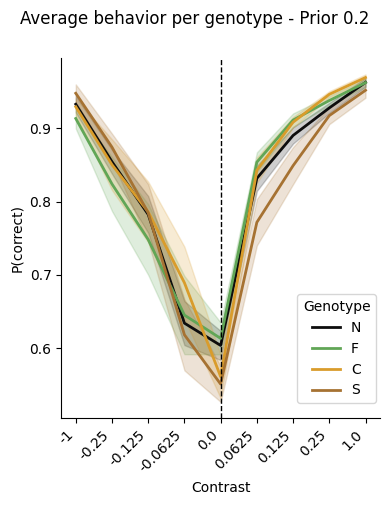


Prior 0.5
    Genotype N
       area left: 0.4618811972381235
       area right: 0.465714116035338

    Genotype F
       area left: 0.4583194929877587
       area right: 0.47315719674460227

    Genotype C
       area left: 0.46417361176477956
       area right: 0.4647869864923249

    Genotype S
       area left: 0.4555087080501266
       area right: 0.4735823883053304



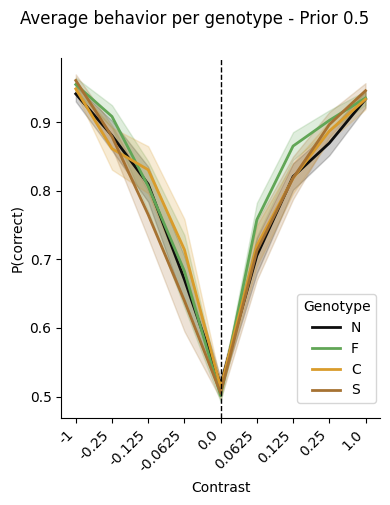


Prior 0.8
    Genotype N
       area left: 0.49594414709661117
       area right: 0.42785777739423153

    Genotype F
       area left: 0.48187835239634447
       area right: 0.44846218191830595

    Genotype C
       area left: 0.4744556265972862
       area right: 0.45103407237170745

    Genotype S
       area left: 0.49412676494411184
       area right: 0.430064939734572



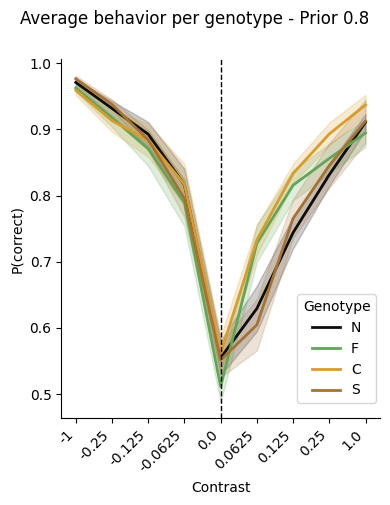

In [ ]:
# Plot average kernel per genotype across all regions 
from matplotlib.lines import Line2D

genotypes = ['N', 'F', 'C', 'S']
#contrast_names = ['cL100', 'cL025', 'cL012', 'cL006', 'c0', 'cR006', 'cR012', 'cR025', 'cR100']
contrast_names = [-1 ,  -0.25  ,  -0.125 ,   -0.0625,    0.  ,    0.0625,   0.125 , 0.25 ,  1.  ]
#colors = {'C':'blue', 'F':'red', 'N':'green', 'S':'orange'}
colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}
map_labels = {'N':'C57BL6', 'F':'Fmr1', 'C':'Cntnap2', 'S':'Shank3'}
genotype_behaviors = {g: [] for g in genotypes}

for prior_label, tuning_curve in {'Prior 0.2': tuning_prior_2, 'Prior 0.5': tuning_prior_5, 'Prior 0.8': tuning_prior_8}.items():

    print(f"\n{prior_label}")
    fig, ax = plt.subplots(1, 1, figsize=(4, 5))

    # Plot mean kernel across animals for each genotype 
    for g in genotypes:
        print(f"    Genotype {g}")
        arrs = tuning_curve[tuning_curve['genotype'] == g][contrast_names].values

        vals = np.stack(arrs) # (all trials, contrastd) 
        #vals[:,:4] = 1-vals[:,:4}

        mean = vals.mean(axis=0) # (1, timepoints)
        std = vals.std(axis=0)
        sem = std / np.sqrt(vals.shape[0])

        total_area = mean.sum(0)
        print(f"       area left: {mean[:4].sum(0)/total_area}")
        print(f"       area right: {mean[5:].sum(0)/total_area}")

        print()

        ax.plot(mean, label=g, color=colors[g], linewidth=2)
        ax.fill_between(np.arange(len(mean)), mean - sem, mean + sem, color=colors[g], alpha=0.2)

    ax.grid(False)
    ax.set_xlabel('Contrast')
    ax.set_xticks(np.arange(len(contrast_names)))

    xindex = np.where(np.array(contrast_names) == 0)[0][0]
    ax.axvline(x=xindex, color='k', linestyle='--', linewidth=1)

    ax.set_xticklabels(contrast_names, rotation=45, ha='right')
    ax.set_ylabel('P(correct)')

    handles = [Line2D([0], [0], color=colors[g], lw=2) for g in genotypes if len(genotype_behaviors[g]) > 0]
    labels = [map_labels[g] for g in map_labels if len(genotype_behaviors[g]) > 0]
    plt.suptitle(f'Average behavior per genotype - {prior_label}', fontsize=12, y=1.00)
    sns.despine()
    plt.tight_layout()
    fig.legend(handles=handles, labels=labels, title='Genotype', bbox_to_anchor=(0.97, 0.2), loc='lower right')
    plt.show()

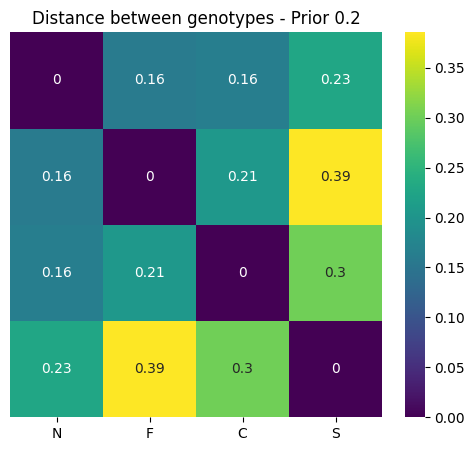

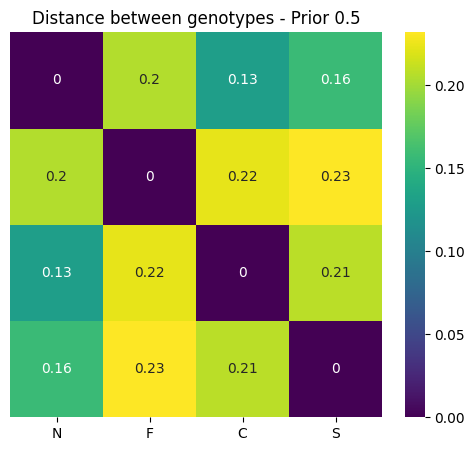

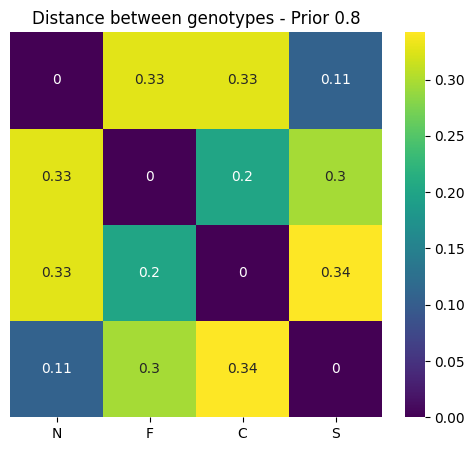

In [9]:
# And plot the heatmap of the distance between genotypes based on mean behavior

# I want to create smth of shape (genotype, contrasts) where each value is the mean correctness across animals for that genotype and contrast
contrast_names = [-1 ,  -0.25  ,  -0.125 ,   -0.0625,    0.  ,    0.0625,   0.125 , 0.25 ,  1.  ]

for prior_label, tuning_curve in {'Prior 0.2': tuning_prior_2, 'Prior 0.5': tuning_prior_5, 'Prior 0.8': tuning_prior_8}.items():

    means = np.zeros((len(genotypes), len(contrast_names)))

    # Plot mean kernel across animals for each genotype 
    for i, g in enumerate(genotypes):
        arrs = tuning_curve[tuning_curve['genotype'] == g][contrast_names].values

        if len(arrs) == 0:
            continue
        vals = np.stack(arrs) # (animals, contrasts) 

        ## Maybe it would be interesting also to look at the dsitances between distributions and not use just the mean? 
        # But for now let's just look at the mean
        mean = vals.mean(axis=0) # (1, contrasts)
        means[i] = mean

    distances = np.abs(means[:, None, :] - means[None, :, :]).sum(-1) # (genotypes, genotypes)
    fig, ax = plt.subplots(1,1, figsize=(6,5))
    sns.heatmap(distances, xticklabels=genotypes, yticklabels=genotypes, annot=True, cmap='viridis',ax=ax,linecolor='white', )
    plt.yticks([], rotation=0, fontsize=10)

    plt.title(f'Distance between genotypes - {prior_label}', fontsize=12)
    plt.show()

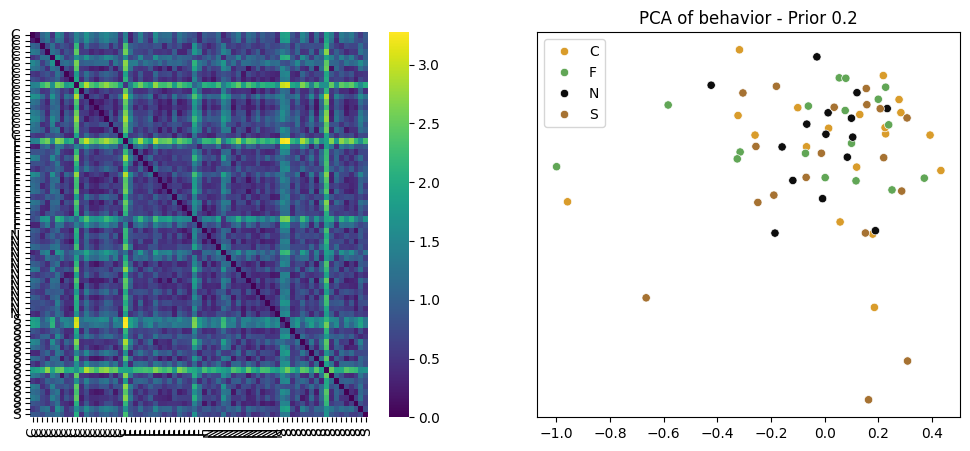

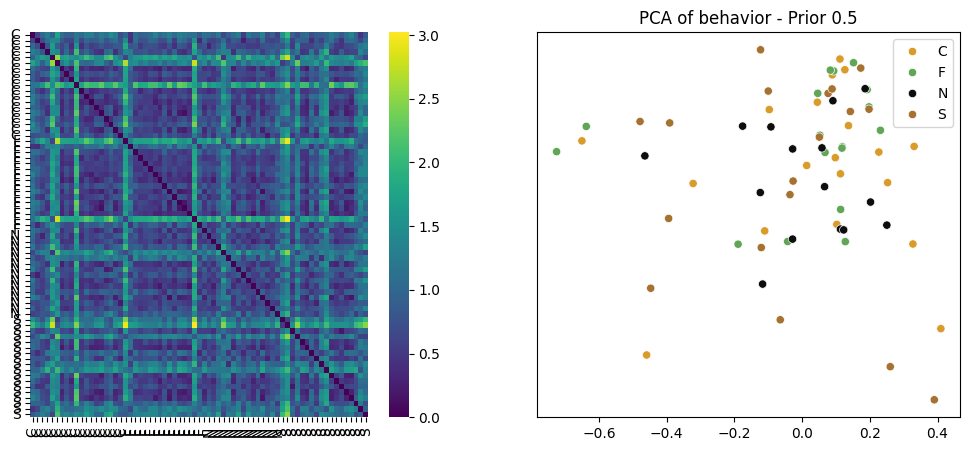

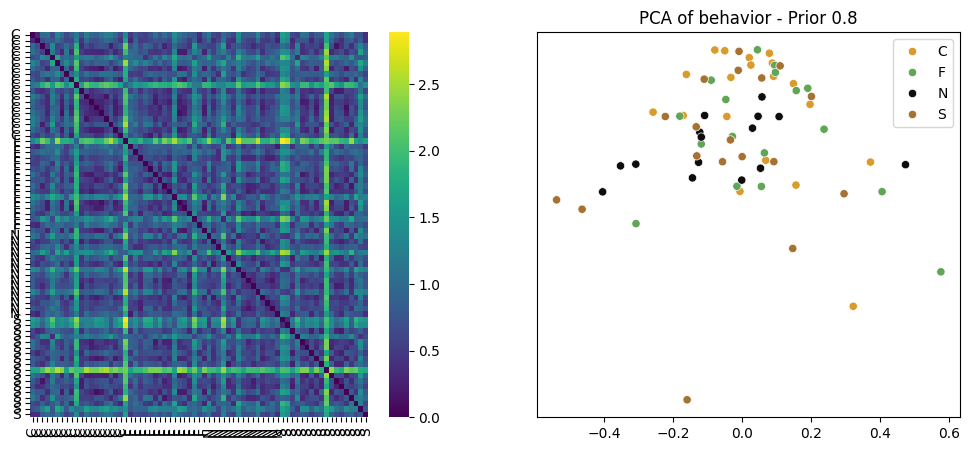

In [16]:
from sklearn.decomposition import PCA
contrast_names = [-1 ,  -0.25  ,  -0.125 ,   -0.0625,    0.  ,    0.0625,   0.125 , 0.25 ,  1.  ]

for prior_label, tuning_curve in {'Prior 0.2': tuning_prior_2, 'Prior 0.5': tuning_prior_5, 'Prior 0.8': tuning_prior_8}.items():
    behavior_vectors = tuning_curve[contrast_names].values # (animals, contrasts)
    genotype_labels = tuning_curve['genotype'].values # (animals,)

    # Compute the correlation between subjects based on their behavior vectors
    #correlation_matrix = 1-np.corrcoef(behavior_vectors)
    correlation_matrix = np.abs(behavior_vectors[:,None,:]-behavior_vectors[None,:,:]).sum(-1) # (animals, animals)
    fig, ax = plt.subplots(1,2, figsize=(12,5))
    sns.heatmap(correlation_matrix, xticklabels=genotype_labels, yticklabels=genotype_labels, cmap='viridis',ax=ax[0],linecolor='white')
    plt.yticks([], rotation=0, fontsize=10)
    plt.title(f'Correlation between subjects based on behavior - {prior_label}', fontsize=12)

    # Compute also the PCA - maybe i will see some clusters that correlate with genotype?
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(behavior_vectors)
    sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=genotype_labels, palette=colors, ax=ax[1])
    plt.title(f'PCA of behavior - {prior_label}', fontsize=12)
    plt.show()  



In [20]:
import ray
from netrep.metrics import LinearMetric
from netrep.metrics import GaussianStochasticMetric

@ray.remote
def _deterministic_metrics_pair(pair,alpha=0.):
    Xi,Xj = pair

    metric = LinearMetric(alpha=alpha,center_columns=True,score_method='euclidean')
    metric.fit(Xi,Xj)
    dist_neural = metric.score(Xi,Xj)
    return dist_neural

# %%
def dsd(pairs,alpha=0.):
    refs = [
        _deterministic_metrics_pair.remote(pair,alpha)
            for pair in pairs
    ]
    D = ray.get(refs)
    D = np.array(D)

    return D

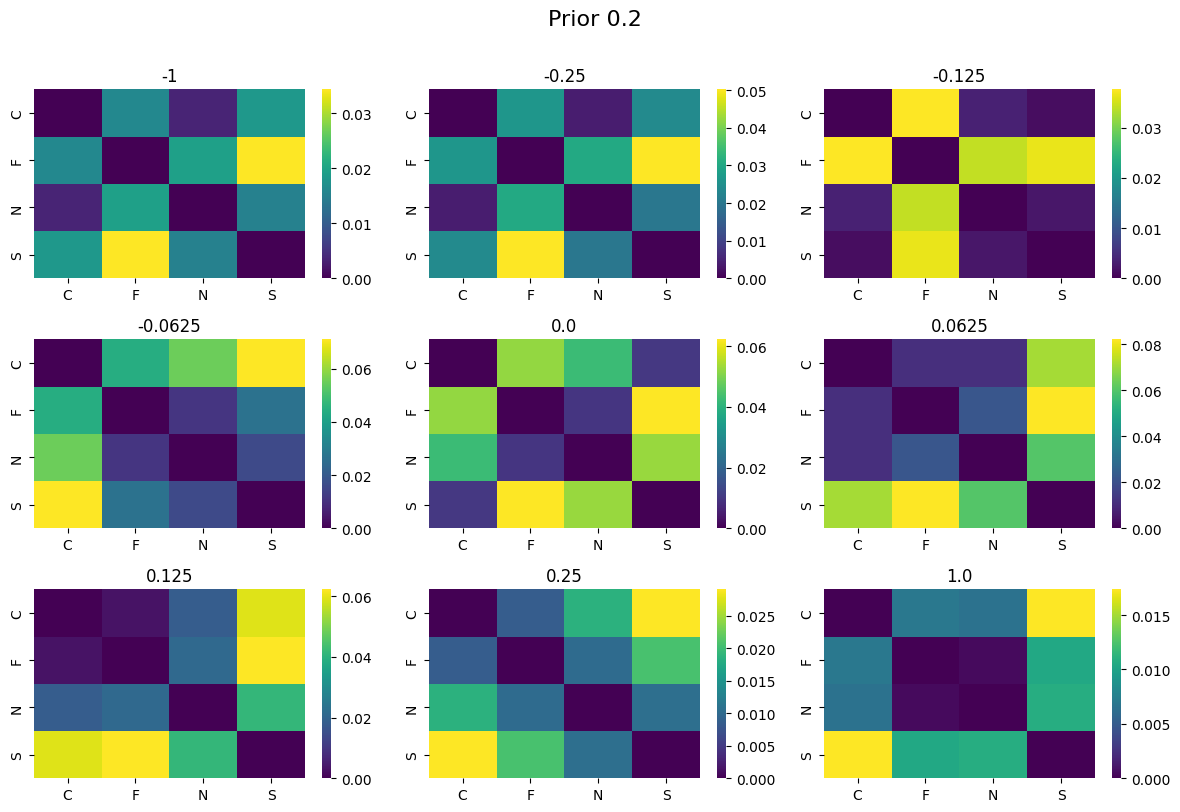

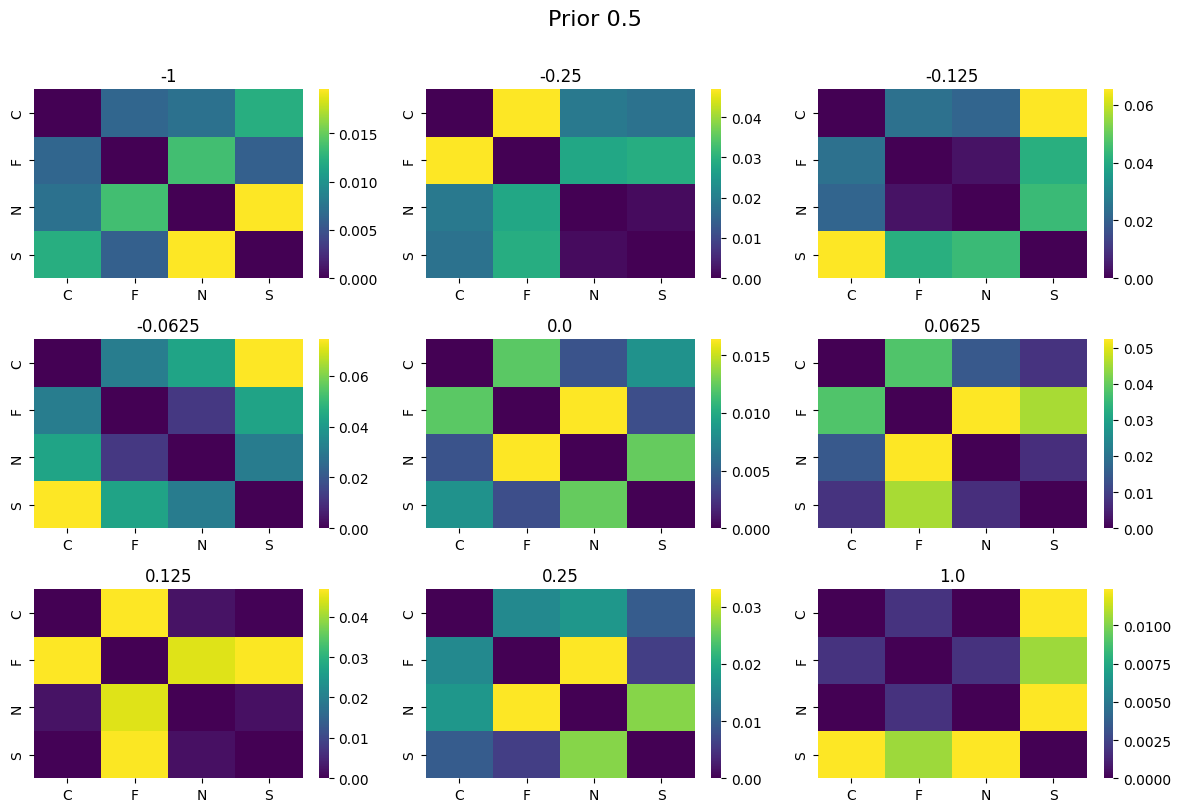

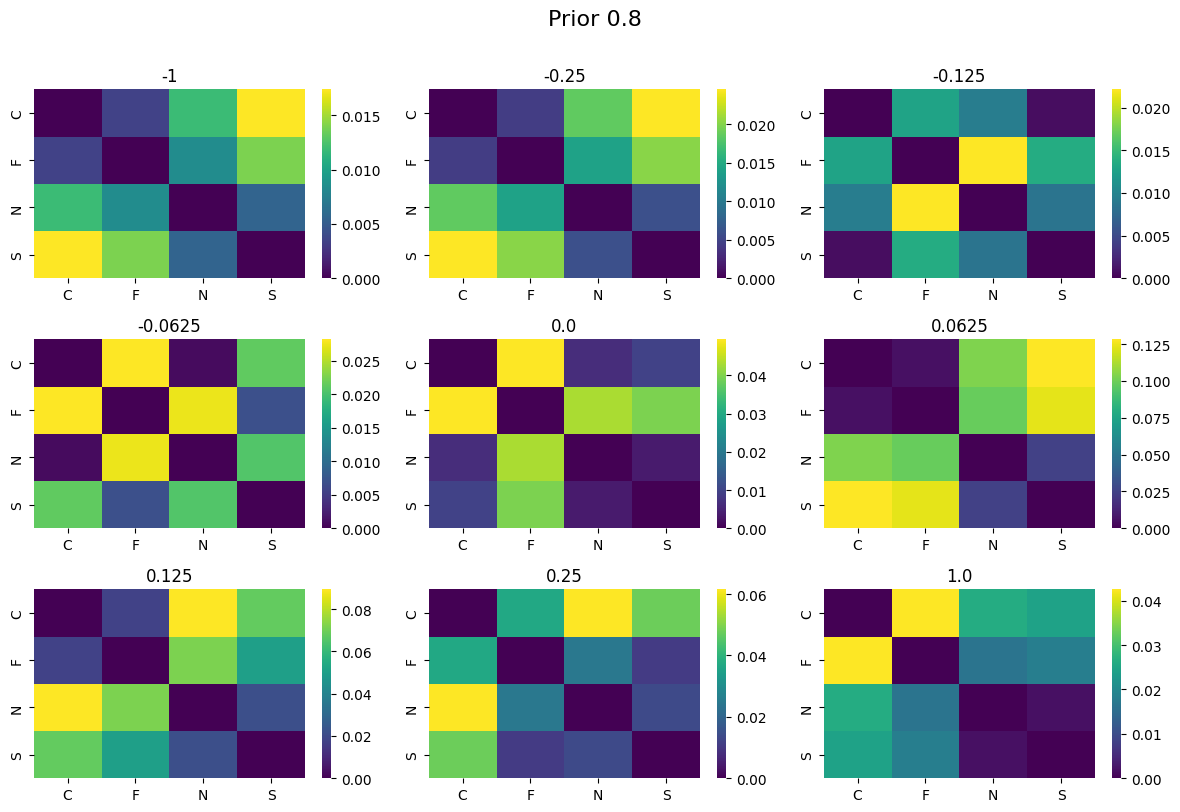

In [49]:
# Now, lets look individually at the distances between genotypes across contrasts
contrasts = ['cL100', 'cL025', 'cL012', 'cL006', 'c0', 'cR006', 'cR012', 'cR025', 'cR100']
contrast_names = [-1 ,  -0.25  ,  -0.125 ,   -0.0625,    0.  ,    0.0625,   0.125 , 0.25 ,  1.  ]

for prior_label, tuning_curve in {'Prior 0.2': tuning_prior_2, 'Prior 0.5': tuning_prior_5, 'Prior 0.8': tuning_prior_8}.items():
    
    fig, axes = plt.subplots(3, 3, figsize=(12, 8))
    axes = axes.flatten()

    behavior_vectors = tuning_curve.groupby('genotype')[contrast_names].mean().values # (genotypes, contrasts)
    genotype_labels = np.unique(tuning_curve['genotype'].values) # (genotypes,)

    distances = np.abs(behavior_vectors[:, None, :] - behavior_vectors[None, :, :]) # (genotypes, genotypes, contrasts)

    for c_idx, contrast in enumerate(contrast_names):
        distances_c = distances[:, :, c_idx]

        sns.heatmap(distances_c, ax=axes[c_idx], xticklabels=genotype_labels, yticklabels=genotype_labels, cmap='viridis')
        axes[c_idx].set_title(contrast, fontsize=12)

    plt.suptitle(prior_label,  fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

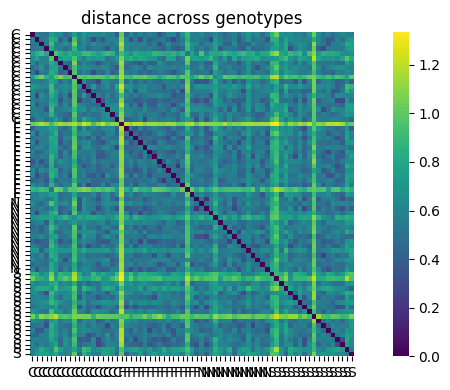

In [24]:
# Using shape metrics
contrast_names = [-1 ,  -0.25  ,  -0.125 ,   -0.0625,    0.  ,    0.0625,   0.125 , 0.25 ,  1.  ]

# What if i combine behaviroal data from all priors and use shape metrics?
all_priors_behavior = []
for prior_label, tuning_curve in {'Prior 0.2': tuning_prior_2, 'Prior 0.5': tuning_prior_5, 'Prior 0.8': tuning_prior_8}.items():
    behavior_vectors = tuning_curve[contrast_names].values # (animals, contrasts)
    all_priors_behavior.append(behavior_vectors)

all_priors_behavior = np.stack(all_priors_behavior).transpose(1,2,0) # (animals, conditions, contrasts)
genotype_labels = tuning_curve['genotype'].values # (animals,)

S = len(all_priors_behavior)

dist_behavioral = dsd([
[all_priors_behavior[i],all_priors_behavior[j]]
for i in range(S) 
for j in range(S)]
).reshape(S,S)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

sns.heatmap(dist_behavioral, xticklabels=genotype_labels, yticklabels=genotype_labels, cmap='viridis', square=True, fmt='.2f', linecolor='white')
plt.title('distance across genotypes', fontsize=12)
plt.yticks(rotation=0, fontsize=10)
plt.xticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()
